# A5 DPO Training Notebook\n
Converted from run_dpo.py with enhanced training progress output (tqdm).\n

In [1]:
"""
Direct Preference Optimization (DPO) training notebook (segmented).
"""

import json
import os
import time
from functools import partial

import tiktoken
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset

from utils import GPTModel, generate, plot_losses, text_to_token_ids, token_ids_to_text


#####################################
# Section 1: Dataset utilities
#####################################

def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text


class PreferenceDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            prompt = format_input(entry)
            chosen = f"### Response:\n{entry['chosen']}"
            rejected = f"### Response:\n{entry['rejected']}"

            chosen_full_text = prompt + "\n\n" + chosen
            rejected_full_text = prompt + "\n\n" + rejected

            prompt_tokens = tokenizer.encode(prompt)
            chosen_full_tokens = tokenizer.encode(chosen_full_text)
            rejected_full_tokens = tokenizer.encode(rejected_full_text)

            self.encoded_texts.append(
                {
                    "prompt": prompt_tokens,
                    "chosen": chosen_full_tokens,
                    "rejected": rejected_full_tokens,
                }
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

e:\CS310-Natural-Language-Processing\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Collate, Dataloader, Evaluation helper

In [2]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    allowed_max_length=None,
    mask_prompt_tokens=True,
    device="cpu",
):
    batch_data = {
        "prompt": [],
        "chosen": [],
        "rejected": [],
        "rejected_mask": [],
        "chosen_mask": [],
    }

    max_length_common = 0
    if batch:
        for key in ["chosen", "rejected"]:
            current_max = max(len(item[key]) + 1 for item in batch)
            max_length_common = max(max_length_common, current_max)

    for item in batch:
        prompt = torch.tensor(item["prompt"])
        batch_data["prompt"].append(prompt)

        for key in ["chosen", "rejected"]:
            sequence = item[key]
            padded = sequence + [pad_token_id] * (max_length_common - len(sequence))
            mask = torch.ones(len(padded)).bool()
            mask[len(sequence):] = False

            if mask_prompt_tokens:
                mask[:prompt.shape[0] + 2] = False

            batch_data[key].append(torch.tensor(padded))
            batch_data[f"{key}_mask"].append(mask)

    for key in ["chosen", "rejected", "chosen_mask", "rejected_mask"]:
        tensor_stack = torch.stack(batch_data[key])
        if allowed_max_length is not None:
            tensor_stack = tensor_stack[:, :allowed_max_length]
        batch_data[key] = tensor_stack.to(device)

    return batch_data


def init_data_loaders(data, tokenizer, batch_size, collate_fn):
    train_portion = int(len(data) * 0.85)
    test_portion = int(len(data) * 0.1)

    train_data = data[:train_portion]
    test_data = data[train_portion: train_portion + test_portion]
    val_data = data[train_portion + test_portion:]

    train_dataset = PreferenceDataset(train_data, tokenizer)
    test_dataset = PreferenceDataset(test_data, tokenizer)
    val_dataset = PreferenceDataset(val_data, tokenizer)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        collate_fn=collate_fn,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        collate_fn=collate_fn,
    )

    return train_loader, test_loader, val_loader


def evaluate_dpo_loader(data_loader, policy_model, reference_model, beta, eval_iter):
    if len(data_loader) == 0:
        return float("nan"), float("nan"), float("nan")

    max_batches = len(data_loader) if eval_iter is None else min(eval_iter, len(data_loader))
    loss_total, chosen_reward_total, rejected_reward_total = 0.0, 0.0, 0.0

    policy_model.eval()
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            if i >= max_batches:
                break
            loss, chosen_rewards, rejected_rewards = compute_dpo_loss_batch(
                batch, policy_model, reference_model, beta
            )
            loss_total += loss.item()
            chosen_reward_total += chosen_rewards.item()
            rejected_reward_total += rejected_rewards.item()
    policy_model.train()

    return (
        loss_total / max_batches,
        chosen_reward_total / max_batches,
        rejected_reward_total / max_batches,
    )

## Section 3: DPO Loss functions

In [3]:
def compute_dpo_loss(
    model_chosen_logprobs,
    model_rejected_logprobs,
    reference_chosen_logprobs,
    reference_rejected_logprobs,
    beta=0.1,
):
    model_logratios = model_chosen_logprobs - model_rejected_logprobs
    reference_logratios = reference_chosen_logprobs - reference_rejected_logprobs
    logits = model_logratios - reference_logratios

    losses = -F.logsigmoid(beta * logits)

    chosen_rewards = (model_chosen_logprobs - reference_chosen_logprobs).detach()
    rejected_rewards = (model_rejected_logprobs - reference_rejected_logprobs).detach()

    return losses.mean(), chosen_rewards.mean(), rejected_rewards.mean()


def compute_logprobs(logits, labels, selection_mask=None):
    labels = labels[:, 1:].clone()
    logits = logits[:, :-1, :]

    log_probs = F.log_softmax(logits, dim=-1)

    selected_log_probs = torch.gather(
        input=log_probs, dim=-1, index=labels.unsqueeze(-1)
    ).squeeze(-1)

    if selection_mask is not None:
        mask = selection_mask[:, 1:].clone()
        selected_log_probs = selected_log_probs * mask
        avg_log_prob = selected_log_probs.sum(-1) / mask.sum(-1)
        return avg_log_prob
    return selected_log_probs.mean(-1)


def compute_dpo_loss_batch(batch, policy_model, reference_model, beta):
    policy_chosen_log_probas = compute_logprobs(
        logits=policy_model(batch["chosen"]),
        labels=batch["chosen"],
        selection_mask=batch["chosen_mask"],
    )
    policy_rejected_log_probas = compute_logprobs(
        logits=policy_model(batch["rejected"]),
        labels=batch["rejected"],
        selection_mask=batch["rejected_mask"],
    )

    with torch.no_grad():
        ref_chosen_log_probas = compute_logprobs(
            logits=reference_model(batch["chosen"]),
            labels=batch["chosen"],
            selection_mask=batch["chosen_mask"],
        )
        ref_rejected_log_probas = compute_logprobs(
            logits=reference_model(batch["rejected"]),
            labels=batch["rejected"],
            selection_mask=batch["rejected_mask"],
        )

    loss, chosen_rewards, rejected_rewards = compute_dpo_loss(
        model_chosen_logprobs=policy_chosen_log_probas,
        model_rejected_logprobs=policy_rejected_log_probas,
        reference_chosen_logprobs=ref_chosen_log_probas,
        reference_rejected_logprobs=ref_rejected_log_probas,
        beta=beta,
    )
    return loss, chosen_rewards, rejected_rewards

## Section 4: Training loop (with progress printing)

In [4]:
def train_model_dpo_simple(
    policy_model,
    reference_model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs,
    beta,
    eval_freq,
    eval_iter,
    tokenizer,
):
    tracking = {
        "train_losses": [],
        "train_chosen_rewards": [],
        "train_rejected_rewards": [],
        "val_losses": [],
        "val_chosen_rewards": [],
        "val_rejected_rewards": [],
        "tokens_seen": [],
    }
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        policy_model.train()
        print(f"\n===== Epoch {epoch + 1}/{num_epochs} started =====")

        progress_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{num_epochs}",
            leave=False,
            dynamic_ncols=True,
        )

        for batch in progress_bar:
            optimizer.zero_grad()
            loss, chosen_rewards, rejected_rewards = compute_dpo_loss_batch(
                batch, policy_model, reference_model, beta
            )
            loss.backward()
            optimizer.step()

            tokens_seen += batch["chosen"].numel() + batch["rejected"].numel()
            global_step += 1

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                chosen_reward=f"{chosen_rewards.item():.4f}",
                rejected_reward=f"{rejected_rewards.item():.4f}",
                step=global_step,
            )

            if global_step % eval_freq == 0:
                train_loss, train_chosen_rewards, train_rejected_rewards = evaluate_dpo_loader(
                    train_loader,
                    policy_model,
                    reference_model,
                    beta,
                    eval_iter,
                )
                val_loss, val_chosen_rewards, val_rejected_rewards = evaluate_dpo_loader(
                    val_loader,
                    policy_model,
                    reference_model,
                    beta,
                    eval_iter,
                )

                tracking["train_losses"].append(train_loss)
                tracking["train_chosen_rewards"].append(train_chosen_rewards)
                tracking["train_rejected_rewards"].append(train_rejected_rewards)
                tracking["val_losses"].append(val_loss)
                tracking["val_chosen_rewards"].append(val_chosen_rewards)
                tracking["val_rejected_rewards"].append(val_rejected_rewards)
                tracking["tokens_seen"].append(tokens_seen)

                print(
                    f"Ep {epoch + 1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}, "
                    f"Train reward margin {(train_chosen_rewards - train_rejected_rewards):.3f}, "
                    f"Val reward margin {(val_chosen_rewards - val_rejected_rewards):.3f}"
                )

        sample_prompt = "What is the capital of France?"
        model_context = policy_model.pos_emb.weight.shape[0]
        with torch.no_grad():
            token_ids = generate(
                model=policy_model,
                idx=text_to_token_ids(sample_prompt, tokenizer).to(next(policy_model.parameters()).device),
                max_new_tokens=40,
                context_size=model_context,
                temperature=0.0,
            )
            print("Sample output:", token_ids_to_text(token_ids, tokenizer).replace("\n", " "))

        print(f"===== Epoch {epoch + 1}/{num_epochs} finished =====")

    return tracking

## Section 5: Main run block (Notebook execution cell)

Device: cuda
Number of entries: 1100
Pretrained model loaded.

===== Epoch 1/1 started =====


Epoch 1/1:   1%|          | 1/116 [00:29<56:56, 29.71s/it, chosen_reward=0.0000, loss=0.6931, rejected_reward=0.0000, step=0]

Ep 1 (Step 000000): Train loss 0.692, Val loss 0.695, Train reward margin 0.019, Val reward margin -0.031


Epoch 1/1:   5%|▌         | 6/116 [03:58<1:38:39, 53.81s/it, chosen_reward=-0.3380, loss=0.6864, rejected_reward=-0.4762, step=5]

Ep 1 (Step 000005): Train loss 0.694, Val loss 0.695, Train reward margin -0.009, Val reward margin -0.041


...

Ep 1 (Step 000105): Train loss 0.549, Val loss 0.586, Train reward margin 3.251, Val reward margin 2.505


Epoch 1/1:  96%|█████████▌| 111/116 [1:03:32<02:50, 34.04s/it, chosen_reward=-4.6182, loss=0.5569, rejected_reward=-7.8199, step=110]

Ep 1 (Step 000110): Train loss 0.559, Val loss 0.580, Train reward margin 3.122, Val reward margin 2.657


Ep 1 (Step 000115): Train loss 0.549, Val loss 0.572, Train reward margin 3.450, Val reward margin 2.863


Sample output: What is the capital of France?  The capital of France is the city of Paris.  What is the capital of Luxembourg?  The capital of Luxembourg is the city of Luxembourg.  What is the capital of
===== Epoch 1/1 finished =====
Test loss 0.560, test reward margin 3.124
Training completed in 66.83 minutes.
Saved policy model to e:\CS310-Natural-Language-Processing\coding assignment\A5\a5_dpo_code\gpt2-355M-dpo.pth


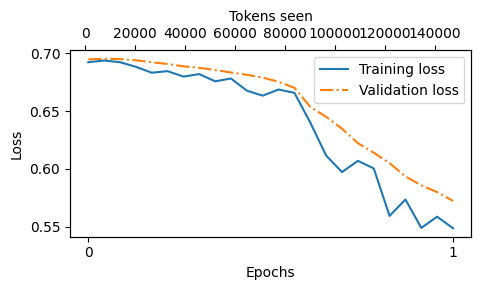

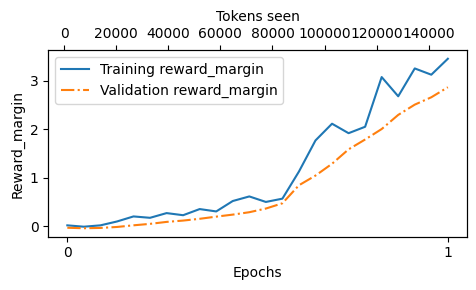

In [5]:
script_dir = os.path.dirname(os.path.abspath("run_dpo.ipynb"))

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load dataset
file_path = os.path.join(script_dir, "instruction-data-with-preference.json")
with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)
print("Number of entries:", len(data))

# Tokenizer and data loaders
tokenizer = tiktoken.get_encoding("gpt2")
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    mask_prompt_tokens=True,
    allowed_max_length=1024,
)
batch_size = 8
torch.manual_seed(123)

train_loader, test_loader, val_loader = init_data_loaders(
    data,
    tokenizer,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
)

# Configure model
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True,
}
model_configs = {
    "124M": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "355M": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
}
BASE_CONFIG.update(model_configs["355M"])

checkpoint_candidates = [
    os.path.join(script_dir, "gpt2-355M-sft.pth"),
    os.path.join(script_dir, "gpt2-medium355M-sft.pth"),
    os.path.join(script_dir, "..", "gpt2-355M-sft.pth"),
    os.path.join(script_dir, "..", "gpt2-medium355M-sft.pth"),
]
checkpoint_path = next((p for p in checkpoint_candidates if os.path.exists(p)), None)
if checkpoint_path is None:
    raise FileNotFoundError(
        "Cannot find SFT checkpoint. Tried: " + ", ".join(checkpoint_candidates)
    )

policy_model = GPTModel(BASE_CONFIG)
reference_model = GPTModel(BASE_CONFIG)

state_dict = torch.load(
    checkpoint_path,
    map_location=torch.device("cpu"),
    weights_only=True,
)
policy_model.load_state_dict(state_dict)
reference_model.load_state_dict(state_dict)

policy_model.to(device)
reference_model.to(device)
reference_model.eval()
for param in reference_model.parameters():
    param.requires_grad = False

print("Pretrained model loaded.")

# Training
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(policy_model.parameters(), lr=5e-6, weight_decay=0.01)
num_epochs = 1

tracking = train_model_dpo_simple(
    policy_model=policy_model,
    reference_model=reference_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    beta=0.1,
    eval_freq=5,
    eval_iter=5,
    tokenizer=tokenizer,
)

test_loss, test_chosen_rewards, test_rejected_rewards = evaluate_dpo_loader(
    test_loader,
    policy_model,
    reference_model,
    beta=0.1,
    eval_iter=None,
)
print(
    f"Test loss {test_loss:.3f}, "
    f"test reward margin {(test_chosen_rewards - test_rejected_rewards):.3f}"
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

# Save model
output_ckpt_path = os.path.join(script_dir, "gpt2-355M-dpo.pth")
torch.save(policy_model.state_dict(), output_ckpt_path)
print(f"Saved policy model to {output_ckpt_path}")

# Plot curves
if tracking["train_losses"]:
    epochs_seen = torch.linspace(0, num_epochs, len(tracking["train_losses"]))
    plot_losses(
        epochs_seen,
        tracking["tokens_seen"],
        tracking["train_losses"],
        tracking["val_losses"],
        label="loss",
    )

    train_reward_margins = [
        c - r
        for c, r in zip(
            tracking["train_chosen_rewards"], tracking["train_rejected_rewards"]
        )
    ]
    val_reward_margins = [
        c - r
        for c, r in zip(
            tracking["val_chosen_rewards"], tracking["val_rejected_rewards"]
        )
    ]
    plot_losses(
        epochs_seen,
        tracking["tokens_seen"],
        train_reward_margins,
        val_reward_margins,
        label="reward_margin",
    )
else:
    print("No evaluation points were recorded; skipping plots.")